# Random Forest — du premier arbre à une forêt d'arbres

## 1. Le point de départ : notre arbre de décision

On cherche à prédire si une intervention sur une infrastructure risque de nécessiter une intervention urgente.

On dispose de variables comme :

* `infrastructure_age`
* `annual_incidents`
* `maintenance_delay`
* `weather_exposure`
* `traffic_level`

et de la cible :

* `urgent_intervention = 0/1`

Un arbre de décision peut produire quelque chose comme :

```mermaid
graph TD
    A[maintenance_delay < 45 jours ?]
    A -- Oui --> B[annual_incidents < 3 ?]
    A -- Non --> C[Intervention urgente]
    B -- Oui --> D[Non urgente]
    B -- Non --> E[Urgente]
    classDef decision fill:#FFF4D6,stroke:#B7791F,color:#5C3B00,stroke-width:2px;
    classDef outcome fill:#E8F5E9,stroke:#2E7D32,color:#1B4332,stroke-width:2px;
    class A,B decision;
    class C,D,E outcome;
```

C'est simple.

Et surtout, c'est **facile à expliquer**.

# 2. Mais un arbre a un problème...

### Question aux apprenants

> Que se passe-t-il si nous construisons l'arbre à partir d'un jeu de données légèrement différent ?

On retire quelques observations.

Ou on en ajoute quelques-unes.

Ou certaines observations atypiques apparaissent.

Et on reconstruit l'arbre.

On peut obtenir :

```mermaid
graph TD
    subgraph Arbre 3
        A3[infrastructure_age < 18] --> B3[traffic_level < 7000]
    end
    subgraph Arbre 2
        A2[annual_incidents < 4] --> B2[infrastructure_age < 25]
    end
    subgraph Arbre 1
        A1[maintenance_delay < 45] --> B1[annual_incidents < 3]
    end
    classDef tree fill:#E8F5E9,stroke:#2E7D32,color:#1B4332,stroke-width:2px;
    class A1,B1,A2,B2,A3,B3 tree;
```

### Le problème

**Les arbres de décision peuvent être très sensibles aux données d'apprentissage.**

C'est ce qu'on appelle une forte **variance**.

# 3. Un arbre peut facilement surapprendre

Un arbre suffisamment profond peut continuer à créer des divisions jusqu'à obtenir des feuilles extrêmement spécialisées.

```mermaid
graph TD
    A[Racine] --> B[...]
    A --> C[...]
    B --> D[...]
    C --> E[...]
    D --> F[observation 1]
    E --> G[observation 2]
    classDef node fill:#E8F5E9,stroke:#2E7D32,color:#1B4332,stroke-width:2px;
    classDef leaf fill:#FCE8E6,stroke:#B42318,color:#7A271A,stroke-width:2px;
    class A,B,C,D,E node;
    class F,G leaf;
```

Sur les données d'entraînement :

```text
Accuracy = 100 %
```

Mais sur de nouvelles données :

```text
Accuracy = 72 %
```

L'arbre a appris **les données**, plutôt que les **règles générales du problème**.

# 4. Première idée : construisons plusieurs arbres

> **« Si un arbre est parfois mauvais, construisons-en plusieurs et faisons-les voter. »**

```mermaid
graph TD
    Data[DONNÉES] --> T1[Arbre 1]
    Data --> T2[Arbre 2]
    Data --> T3[Arbre 3]
    T1 --> O1[Urgent]
    T2 --> O2[Pas urgent]
    T3 --> O3[Urgent]
    O1 --> V[VOTE]
    O2 --> V
    O3 --> V
    V --> U[URGENT]
    classDef data fill:#E8F1F8,stroke:#1F5A7A,color:#12344D,stroke-width:2px;
    classDef tree fill:#E8F5E9,stroke:#2E7D32,color:#1B4332,stroke-width:2px;
    classDef outcome fill:#FCE8E6,stroke:#B42318,color:#7A271A,stroke-width:2px;
    classDef aggregate fill:#FFF4D6,stroke:#B7791F,color:#5C3B00,stroke-width:2px;
    class Data data;
    class T1,T2,T3 tree;
    class O1,O2,O3,U outcome;
    class V aggregate;
```

Mais il y a un problème.

Si nous construisons **100 fois exactement le même arbre avec exactement les mêmes données**, nous obtenons 100 fois la même réponse.

```text
Arbre 1 → Urgent
Arbre 2 → Urgent
Arbre 3 → Urgent
...
Arbre 100 → Urgent
```

Le vote ne sert à rien.

Il faut donc rendre les arbres **différents**.

Et c'est précisément l'idée fondamentale de Random Forest.

# 5. L'idée centrale : créer des arbres différents

Random Forest repose sur deux mécanismes essentiels :

### 1. Des données différentes

Chaque arbre apprend sur un échantillon différent du jeu d'entraînement.

### 2. Des variables différentes

Lors de la construction de chaque séparation, l'arbre ne considère qu'un sous-ensemble aléatoire des variables.

On obtient donc une forêt :

```mermaid
graph TD
    D[Données] --> E1[échantillon A]
    D --> E2[échantillon B]
    D --> E3[échantillon C]
    E1 --> A1[Arbre 1]
    E2 --> A2[Arbre 2]
    E3 --> A3[Arbre 3]
    A1 --> V[Vote]
    A2 --> V
    classDef data fill:#E8F1F8,stroke:#1F5A7A,color:#12344D,stroke-width:2px;
    classDef sample fill:#FFF4D6,stroke:#B7791F,color:#5C3B00,stroke-width:2px;
    classDef tree fill:#E8F5E9,stroke:#2E7D32,color:#1B4332,stroke-width:2px;
    classDef aggregate fill:#FFF4D6,stroke:#B7791F,color:#5C3B00,stroke-width:2px;
    classDef prediction fill:#FCE8E6,stroke:#B42318,color:#7A271A,stroke-width:2px;
    class D data;
    class E1,E2,E3 sample;
    class A1,A2,A3 tree;
    class V aggregate;
    class P prediction;
    A3 --> V
    V --> P[Prédiction]
```

# 6. Premier mécanisme : le bootstrap

Le premier mécanisme s'appelle le **bootstrap sampling**.

Supposons que notre dataset contienne :

```text
A B C D E F G H
```

On veut construire un arbre.

On tire aléatoirement des observations **avec remise** :

```text
A D D F G G H A
```

On obtient donc un jeu d'apprentissage différent.

Pour un autre arbre :

```text
B B C E F H H D
```

Et pour un troisième :

```text
A C C D E E G H
```

Chaque arbre voit donc une version légèrement différente des données.

# 7. Pourquoi « avec remise » ?

Si on tire :

```text
A → D → F → B
```

et que le tirage est **avec remise**, D peut être tiré à nouveau :

```text
A → D → D → F → B
```

Une même observation peut donc apparaître plusieurs fois.

Certaines observations ne seront jamais sélectionnées.

C'est ce mécanisme qui permet de créer des datasets différents à partir du même dataset initial.

# 8. Deuxième mécanisme : un sous-ensemble de variables

Le bootstrap ne suffit pas.

Imaginons que nous ayons :

```text
infrastructure_age
annual_incidents
maintenance_delay
weather_exposure
traffic_level
```

Pour une séparation donnée, Random Forest peut décider de ne considérer que :

```text
annual_incidents
traffic_level
```

À une autre séparation :

```text
infrastructure_age
weather_exposure
```

Et pour un autre arbre :

```text
maintenance_delay
traffic_level
```

Cela oblige les arbres à explorer **des chemins différents**.

# 9. Pourquoi rendre les arbres différents ?

Imaginons 5 arbres :

```text
Arbre 1 → Urgent
Arbre 2 → Urgent
Arbre 3 → Urgent
Arbre 4 → Urgent
Arbre 5 → Urgent
```

Cela semble très convaincant.

Mais si les cinq arbres font exactement les mêmes erreurs :

```text
Erreur
Erreur
Erreur
Erreur
Erreur
```

la forêt ne nous apporte pas grand-chose.

En revanche :

```text
Arbre 1 → erreur
Arbre 2 → correct
Arbre 3 → correct
Arbre 4 → correct
Arbre 5 → correct
```

alors le vote permet de corriger l'erreur du premier arbre.

### Idée clé

> **La puissance d'une Random Forest ne vient pas seulement du nombre d'arbres. Elle vient de la diversité des arbres.**

# 10. Le vote majoritaire

Pour une classification, chaque arbre donne une prédiction.

Par exemple :

| Arbre | Prédiction  |
| ----- | ----------- |
| 1     | Urgente     |
| 2     | Urgente     |
| 3     | Non urgente |
| 4     | Urgente     |
| 5     | Non urgente |
| 6     | Urgente     |
| 7     | Urgente     |

On compte les votes :

```text
Urgente      : 5
Non urgente  : 2
```

La Random Forest prédit :

```text
→ Urgente
```

Mathématiquement, on peut présenter simplement :

$$\hat{y} = \operatorname{mode} \left( T_1(x),T_2(x),...,T_B(x) \right)$$

où chaque $T_b$ est un arbre et en mathématiques le mode est la valeur ou la catégorie qui apparaît le plus souvent dans une série de données.

# 11. Et pour la régression ?

Même principe, mais au lieu de voter, on fait généralement une **moyenne**.

Par exemple :

```text
Arbre 1 → 125 jours
Arbre 2 → 132 jours
Arbre 3 → 128 jours
Arbre 4 → 121 jours
Arbre 5 → 129 jours
```

La forêt prédit :

$$\frac{125+132+128+121+129}{5}=127$$

Donc :

```text
→ 127 jours
```

> **Random Forest peut être utilisée aussi bien en classification qu'en régression.**

# 12. Le schéma global de l'algorithme

Je pense qu'il est intéressant de terminer la partie conceptuelle par un schéma que les apprenants peuvent retenir.

```mermaid
graph TD
    DI[DATASET INITIAL] --> B1[Bootstrap 1]
    DI --> B2[Bootstrap 2]
    DI --> B3[Bootstrap 3]
    B1 --> A1[Arbre 1]
    B2 --> A2[Arbre 2]
    B3 --> A3[Arbre 3]
    VA[Variables aléatoires] -.-> A1
    VA -.-> A2
    VA -.-> A3
    A1 --> MA[MULTIPLES ARBRES]
    A2 --> MA
    A3 --> MA
    MA --> AG[AGRÉGATION]
    AG --> C[Classification]
    AG --> R[Régression]
    C --> V[Vote]
    R --> M[Moyenne]
    V --> P[PRÉDICTION]
    M --> P
    classDef data fill:#E8F1F8,stroke:#1F5A7A,color:#12344D,stroke-width:2px;
    classDef sample fill:#FFF4D6,stroke:#B7791F,color:#5C3B00,stroke-width:2px;
    classDef tree fill:#E8F5E9,stroke:#2E7D32,color:#1B4332,stroke-width:2px;
    classDef feature fill:#F3E8FF,stroke:#7E22CE,color:#4A1D70,stroke-width:2px;
    classDef aggregate fill:#FFF4D6,stroke:#B7791F,color:#5C3B00,stroke-width:2px;
    classDef prediction fill:#FCE8E6,stroke:#B42318,color:#7A271A,stroke-width:2px;
    class DI data;
    class B1,B2,B3 sample;
    class A1,A2,A3 tree;
    class VA feature;
    class MA,AG aggregate;
    class C,R,V,M,P prediction;
```

# 13. Random Forest vs arbre unique

| Arbre de décision             | Random Forest                  |
| ----------------------------- | ------------------------------ |
| Un seul arbre                 | Plusieurs arbres               |
| Facile à visualiser           | Plus difficile à interpréter   |
| Peut avoir une forte variance | Réduit la variance             |
| Peut surapprendre             | Plus robuste                   |
| Sensible aux données          | Moins sensible                 |
| Rapide à entraîner            | Plus coûteux                   |
| Très interprétable            | Interprétabilité plus complexe |

> **Random Forest ne cherche pas à construire le meilleur arbre. Elle cherche à construire une bonne collection d'arbres différents.**

# 14. Une analogie

### Un expert

Vous demandez à une personne :

> « Cette infrastructure nécessite-t-elle une intervention urgente ? »

Elle analyse les données et répond :

```text
URGENTE
```

Mais cette personne peut se tromper.

### Un comité d'experts

Vous posez la même question à 100 experts :

```text
Expert 1  → Urgente
Expert 2  → Non urgente
Expert 3  → Urgente
Expert 4  → Urgente
...
Expert 100 → Urgente
```

Vous faites voter le groupe.

```text
73 → Urgente
27 → Non urgente
```

Vous avez davantage confiance dans la décision collective.

Mais il y a une condition :

> Les experts doivent être **suffisamment indépendants et diversifiés**.

C'est exactement l'idée de Random Forest.

# 15. Passage à scikit-learn

```py
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
```

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

### `n_estimators`

Nombre d'arbres :

In [ ]:
n_estimators=10
n_estimators=100
n_estimators=500

Plus d'arbres signifie généralement une forêt plus stable, avec un coût de calcul supérieur.

### `max_depth`

Profondeur maximale des arbres.

In [ ]:
max_depth=5

permet de limiter la complexité.

### `max_features`

Nombre de variables considérées lors de la recherche d'une séparation.

C'est un paramètre **particulièrement important pour comprendre Random Forest**, puisqu'il participe directement à la diversification des arbres.

# 16. Un point important : Random Forest ne « corrige » pas les arbres

Une confusion fréquente est :

> « On construit un arbre, puis le deuxième corrige le premier, puis le troisième corrige le deuxième. »

**Ce n'est pas ce que fait Random Forest.**

C'est plutôt :

```mermaid
graph LR
    A1[Arbre 1] --> AG[Agrégation]
    A2[Arbre 2] --> AG
    A3[Arbre 3] --> AG
    A4[Arbre 4] --> AG
    A5[Arbre 5] --> AG
    classDef tree fill:#E8F5E9,stroke:#2E7D32,color:#1B4332,stroke-width:2px;
    classDef aggregate fill:#FFF4D6,stroke:#B7791F,color:#5C3B00,stroke-width:2px;
    class A1,A2,A3,A4,A5 tree;
    class AG aggregate;
```

Les arbres sont construits **indépendamment**.

C'est très différent du **boosting**, qui sera introduit ensuite.

> **Random Forest : construire des modèles diversifiés en parallèle.**

> **Boosting : construire progressivement des modèles qui se concentrent sur les erreurs des précédents.**

# 17. Stabilisation de la frontière de décision

> « Random Forest réduit la variance. »

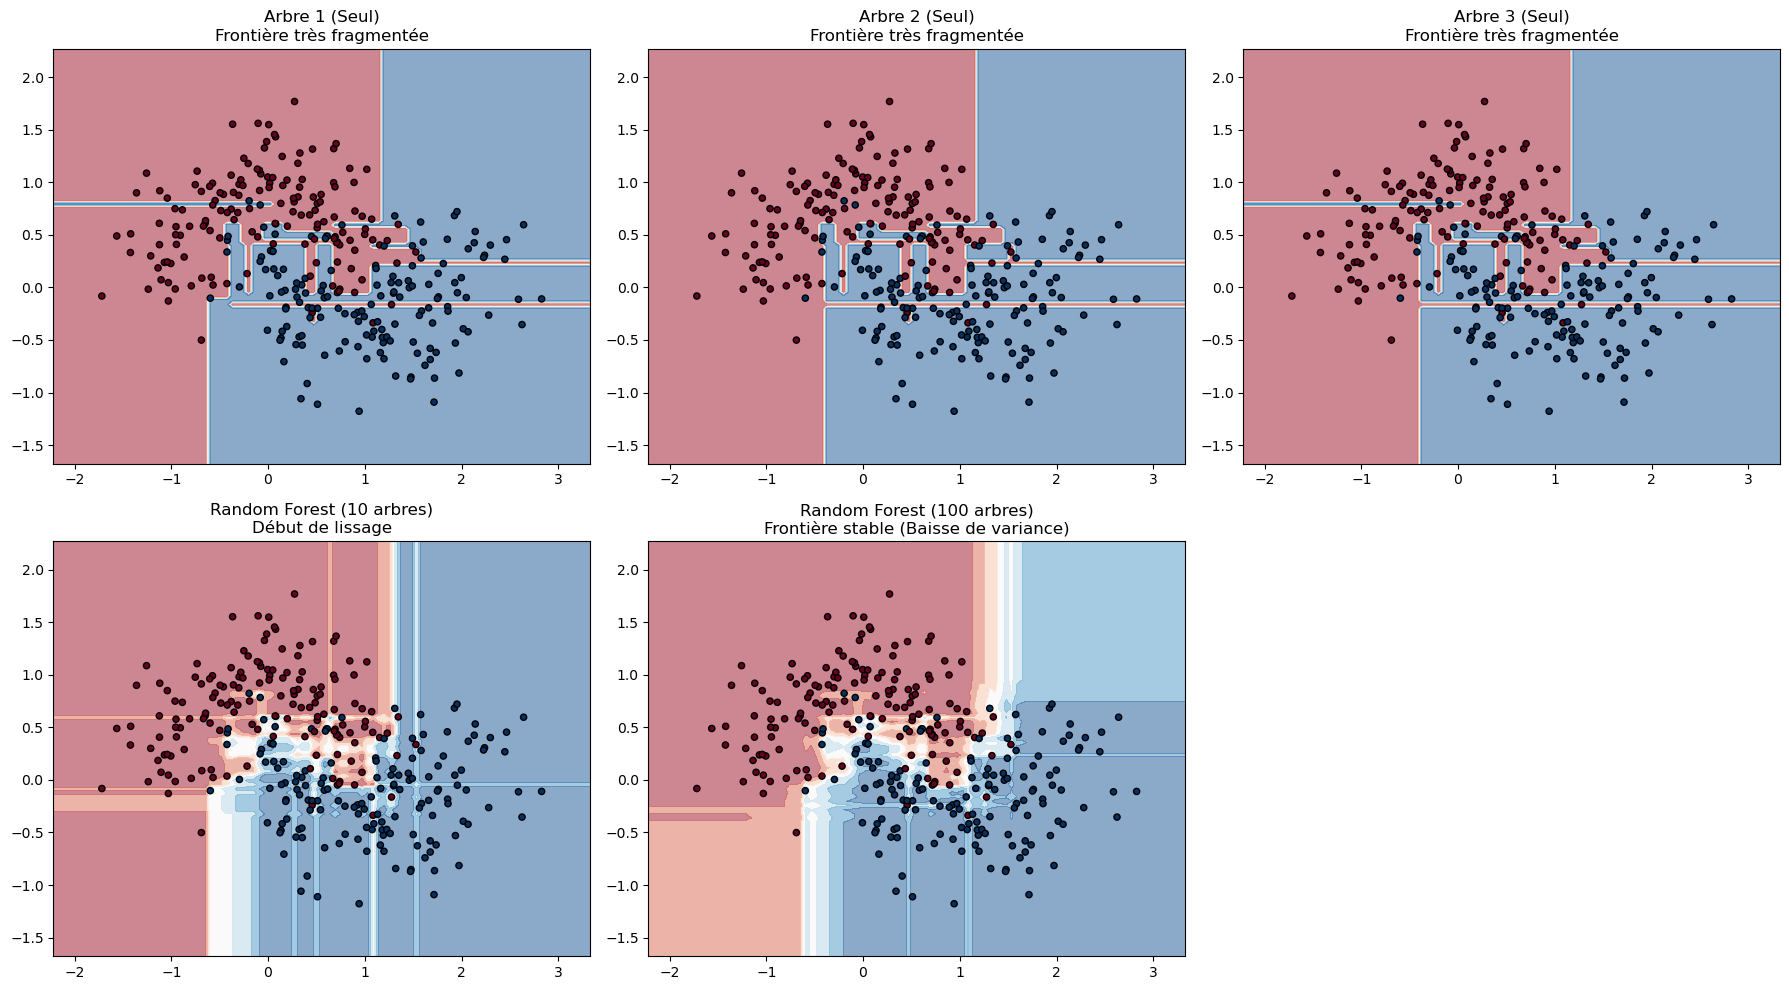

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Génération d'un jeu de données 2D (les "moons") avec du bruit
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# 2. Configuration de la figure (2 lignes, 3 colonnes)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 3. Entraînement et affichage de 3 arbres de décision distincts
for i in range(3):
    # En changeant le random_state, l'arbre se construit légèrement différemment
    tree = DecisionTreeClassifier(random_state=i)
    tree.fit(X, y)
    
    DecisionBoundaryDisplay.from_estimator(
        tree, X, cmap=plt.cm.RdBu, alpha=0.5, ax=axes[i], eps=0.5
    )
    axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', s=20)
    axes[i].set_title(f"Arbre {i+1} (Seul)\nFrontière très fragmentée")

# 4. Entraînement d'un Random Forest avec 10 arbres
rf_10 = RandomForestClassifier(n_estimators=10, random_state=42)
rf_10.fit(X, y)

DecisionBoundaryDisplay.from_estimator(
    rf_10, X, cmap=plt.cm.RdBu, alpha=0.5, ax=axes[3], eps=0.5
)
axes[3].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', s=20)
axes[3].set_title("Random Forest (10 arbres)\nDébut de lissage")

# 5. Entraînement d'un Random Forest avec 100 arbres
rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100.fit(X, y)

DecisionBoundaryDisplay.from_estimator(
    rf_100, X, cmap=plt.cm.RdBu, alpha=0.5, ax=axes[4], eps=0.5
)
axes[4].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', s=20)
axes[4].set_title("Random Forest (100 arbres)\nFrontière stable (Baisse de variance)")

# 6. Nettoyage de la dernière case vide
axes[5].axis('off')

plt.tight_layout()
plt.show()


Le surapprentissage des arbres isolés : Les graphiques 1, 2 et 3 montre des frontières de décision très irrégulières. Chaque arbre tente de classer parfaitement les points d'entraînement, incluant le "bruit".

La transition avec 10 arbres : Le graphique 4 montre que les artefacts commencent à s'effacer, mais que la frontière hésite encore par endroits.

La généralisation avec 100 arbres : Le graphique 5 révèle une séparation lisse et naturelle des deux classes principales. La variance est réduite et le modèle généralise mieux.

# 18. Est-ce que 10 000 arbres donnent forcément un meilleur modèle ?

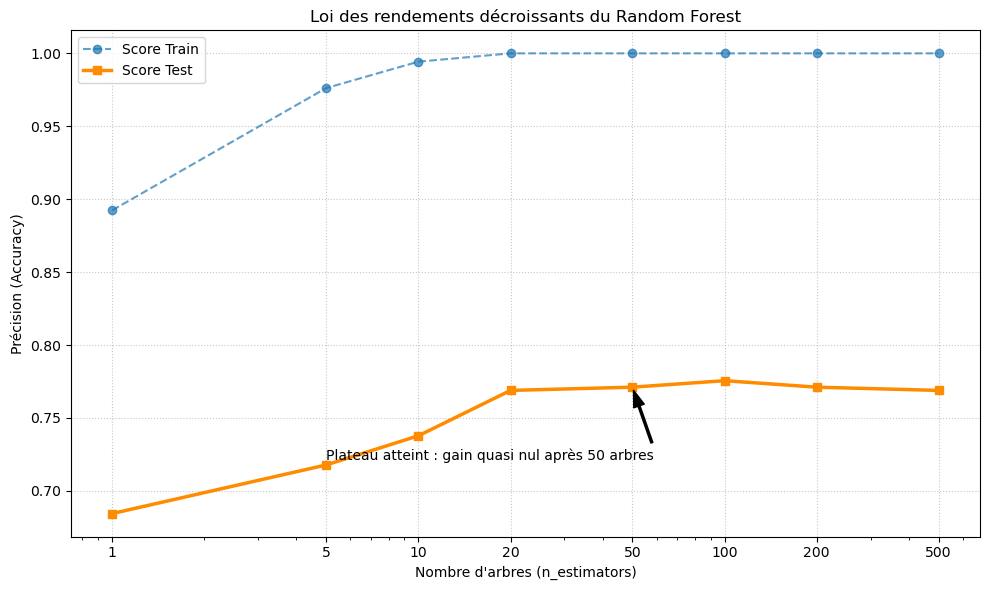

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Dataset ajusté CORRIGÉ
# Utilisation de flip_y et class_sep au lieu de noise pour borner la performance
X, y = make_classification(n_samples=1500, n_features=10, n_informative=4, 
                           n_redundant=2, flip_y=0.05, class_sep=0.8, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Liste plus granulaire pour bien voir la cassure de la courbe
n_arbres_liste = [1, 5, 10, 20, 50, 100, 200, 500]
scores_train = []
scores_test = []

# 3. Entraînement
for n in n_arbres_liste:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    scores_train.append(accuracy_score(y_train, rf.predict(X_train)))
    scores_test.append(accuracy_score(y_test, rf.predict(X_test)))

# 4. Tracé
plt.figure(figsize=(10, 6))

plt.plot(n_arbres_liste, scores_train, marker='o', label='Score Train', linestyle='--', alpha=0.7)
plt.plot(n_arbres_liste, scores_test, marker='s', label='Score Test', linewidth=2.5, color='darkorange')

plt.xscale('log')
plt.xticks(n_arbres_liste, n_arbres_liste)
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("Précision (Accuracy)")
plt.title("Loi des rendements décroissants du Random Forest")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Annotation calée sur le nouveau point de plateau (autour de 50)
plt.annotate('Plateau atteint : gain quasi nul après 50 arbres', 
             xy=(50, scores_test[4]), 
             xytext=(5, scores_test[4] - 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

plt.tight_layout()
plt.show()


Le bond initial : Le passage de 1 à 10 ou 50 arbres apporte un gain de performance massif et très visible sur la courbe orange (Test).

La loi des rendements décroissants : Passer de 100 à 500 arbres demande 5 fois plus de temps de calcul, mais la courbe devient presque parfaitement plate. Le modèle a atteint sa capacité maximale de généralisation.

La réponse à la question des 10 000 arbres : Ajouter des arbres n'entraîne pas de surapprentissage (la courbe de test ne redescend pas, contrairement à un Boosting qui serait mal paramétré), mais cela gaspille inutilement de la mémoire et du temps de calcul (RAM et CPU).

# 19. Comparer les modèles

```mermaid
graph TD
    A[Arbre] -->|problème: variance| B[Plusieurs arbres]
    B -->|diversité| C[Bootstrap]
    B -->|diversité| D[Variables aléatoires]
    C --> RF[Random Forest]
    D --> RF
    RF -->|agrégation| PR[prédiction robuste]
    classDef tree fill:#E8F5E9,stroke:#2E7D32,color:#1B4332,stroke-width:2px;
    classDef mechanism fill:#FFF4D6,stroke:#B7791F,color:#5C3B00,stroke-width:2px;
    classDef forest fill:#E8F1F8,stroke:#1F5A7A,color:#12344D,stroke-width:2px;
    classDef prediction fill:#FCE8E6,stroke:#B42318,color:#7A271A,stroke-width:2px;
    class A tree;
    class B,C,D mechanism;
    class RF forest;
    class PR prediction;
```

Et à la fin :

| Modèle            | Idée                                                             |
| ----------------- | ---------------------------------------------------------------- |
| Arbre de décision | Un modèle simple basé sur des règles                             |
| Random Forest     | Beaucoup d'arbres diversifiés + agrégation                       |
| Gradient Boosting | Des arbres construits progressivement pour améliorer les erreurs |